## How well do jobs and skills pay for Data Analysis?

### Methodology

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysis
3. Visualize for highest paying skills and most demanded skills

In [26]:
# Import Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
# Filter for the job titles and country
df_MX = df[(df['job_country'] == 'Mexico')].dropna(subset=['salary_year_avg'])

In [5]:
job_titles = df_MX['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Analyst',
 'Data Scientist',
 'Data Engineer',
 'Senior Data Engineer',
 'Senior Data Scientist',
 'Machine Learning Engineer']

In [6]:
df_MX_top6 = df_MX[df_MX['job_title_short'].isin(job_titles)]

In [13]:
job_order = df_MX_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

In [18]:
df_MX_top6.groupby('job_title_short')['salary_year_avg'].median()

job_title_short
Data Analyst                  98500.0
Data Engineer                133500.0
Data Scientist               113225.0
Machine Learning Engineer    101029.0
Senior Data Engineer         147500.0
Senior Data Scientist        157500.0
Name: salary_year_avg, dtype: float64

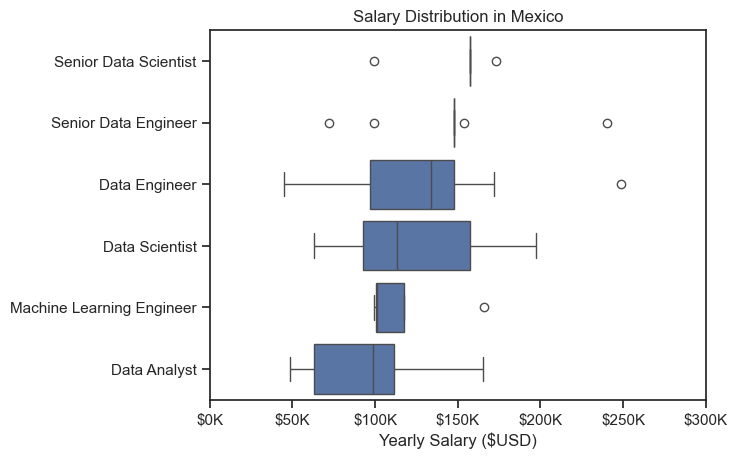

In [14]:
sns.boxplot(data=df_MX_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distribution in Mexico')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 300000)
plt.show()

# Investigate Median Salary VS Skill for Data Analysts

In [27]:
df_DA_MX = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Mexico')].copy()

df_DA_MX = df_DA_MX.dropna(subset=['salary_year_avg'])

In [28]:
df_DA_MX = df_DA_MX.explode('job_skills')

df_DA_MX[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
5478,70500.0,sql
116903,99150.0,python
116903,99150.0,plotly
116903,99150.0,pandas
116903,99150.0,seaborn


In [32]:
df_DA_top_pay = df_DA_MX.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
scala,2,147500.0
spark,2,129337.5
go,1,111202.0
aws,3,111175.0
kafka,1,111175.0
redshift,1,111175.0
r,4,111175.0
python,8,111175.0
looker,5,111175.0


In [31]:
df_DA_skills = df_DA_MX.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
sql,11,111175.0
python,8,111175.0
looker,5,111175.0
r,4,111175.0
aws,3,111175.0
excel,16,98825.0
power bi,12,89675.0
tableau,13,80850.0
sheets,7,57500.0


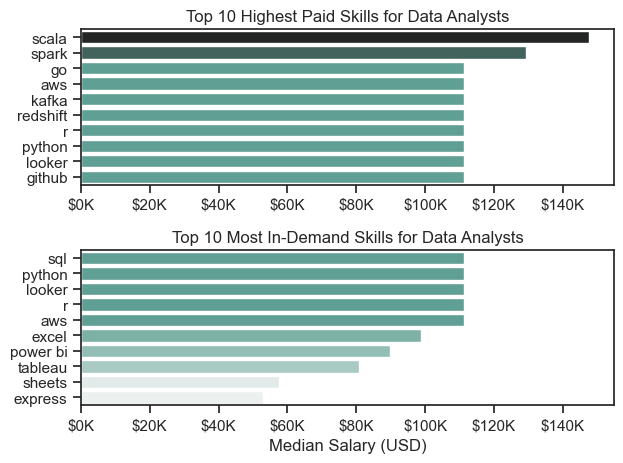

In [37]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style="ticks")

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:#5A9_r')
ax[0].legend().remove()

# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analysts
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:#5A9')
ax[1].legend().remove()

# df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()
plt.show()